## 02 · Preprocessing

**Goals**
1. Merge `train.csv` + `features.csv` + `stores.csv` into one DataFrame.
2. Drop MarkDown columns (>50% missing).
3. Forward-fill sparse external features (CPI, Unemployment, etc.).
4. Inspect the cleaned merged dataset.
5. Validate the time-based train / val / test split boundaries.

---
All preprocessing logic lives in `src/preprocessing.py` and `src/data_loader.py`.

In [2]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.data_loader    import load_raw_data, merge_datasets
from src.preprocessing  import fill_missing_externals, encode_store_type
from src.config         import TRAIN_END_DATE, VAL_END_DATE, PRIMARY_COLOR, SECONDARY_COLOR

plt.rcParams["figure.dpi"] = 110
print("Imports OK")

Imports OK


---
## 1 · Load & Merge

In [3]:
train_df, features_df, stores_df = load_raw_data()
df = merge_datasets(train_df, features_df, stores_df)

print("\nColumns after merge:")
print(df.columns.tolist())
display(df.head(3))

train_df    : 421,570 rows × 5 cols
features_df :   8,190 rows × 12 cols
stores_df   :      45 rows × 3 cols
Dropped MarkDown columns (>50% missing): ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Merged shape : 421,570 rows × 11 cols
Date range   : 2010-02-05 → 2012-10-26

Columns after merge:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Type', 'Size']


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,29,5,2010-02-05,15552.08,False,24.36,2.788,131.527903,10.064,B,93638
2,29,6,2010-02-05,3200.22,False,24.36,2.788,131.527903,10.064,B,93638


---
## 2 · Post-Merge Missing Values

In [4]:
miss = df.isnull().sum()
miss = miss[miss > 0]
if len(miss):
    print("Remaining NaN after merge:")
    print(miss.to_string())
else:
    print("No missing values after merge. ✓")

No missing values after merge. ✓


In [5]:
print("Filling missing externals per store:")
df = fill_missing_externals(df)

remaining = df.isnull().sum().sum()
print(f"\nTotal NaN remaining: {remaining}")

Filling missing externals per store:

Total NaN remaining: 0


---
## 3 · Store Type Encoding

In [6]:
df = encode_store_type(df)
print("Type dummy columns added: Type_A, Type_B, Type_C")
print(df[["Type", "Type_A", "Type_B", "Type_C"]].drop_duplicates().sort_values("Type").to_string(index=False))

Type dummy columns added: Type_A, Type_B, Type_C
Type  Type_A  Type_B  Type_C
   A       1       0       0
   B       0       1       0
   C       0       0       1


---
## 4 · Distribution of Key Numerical Features

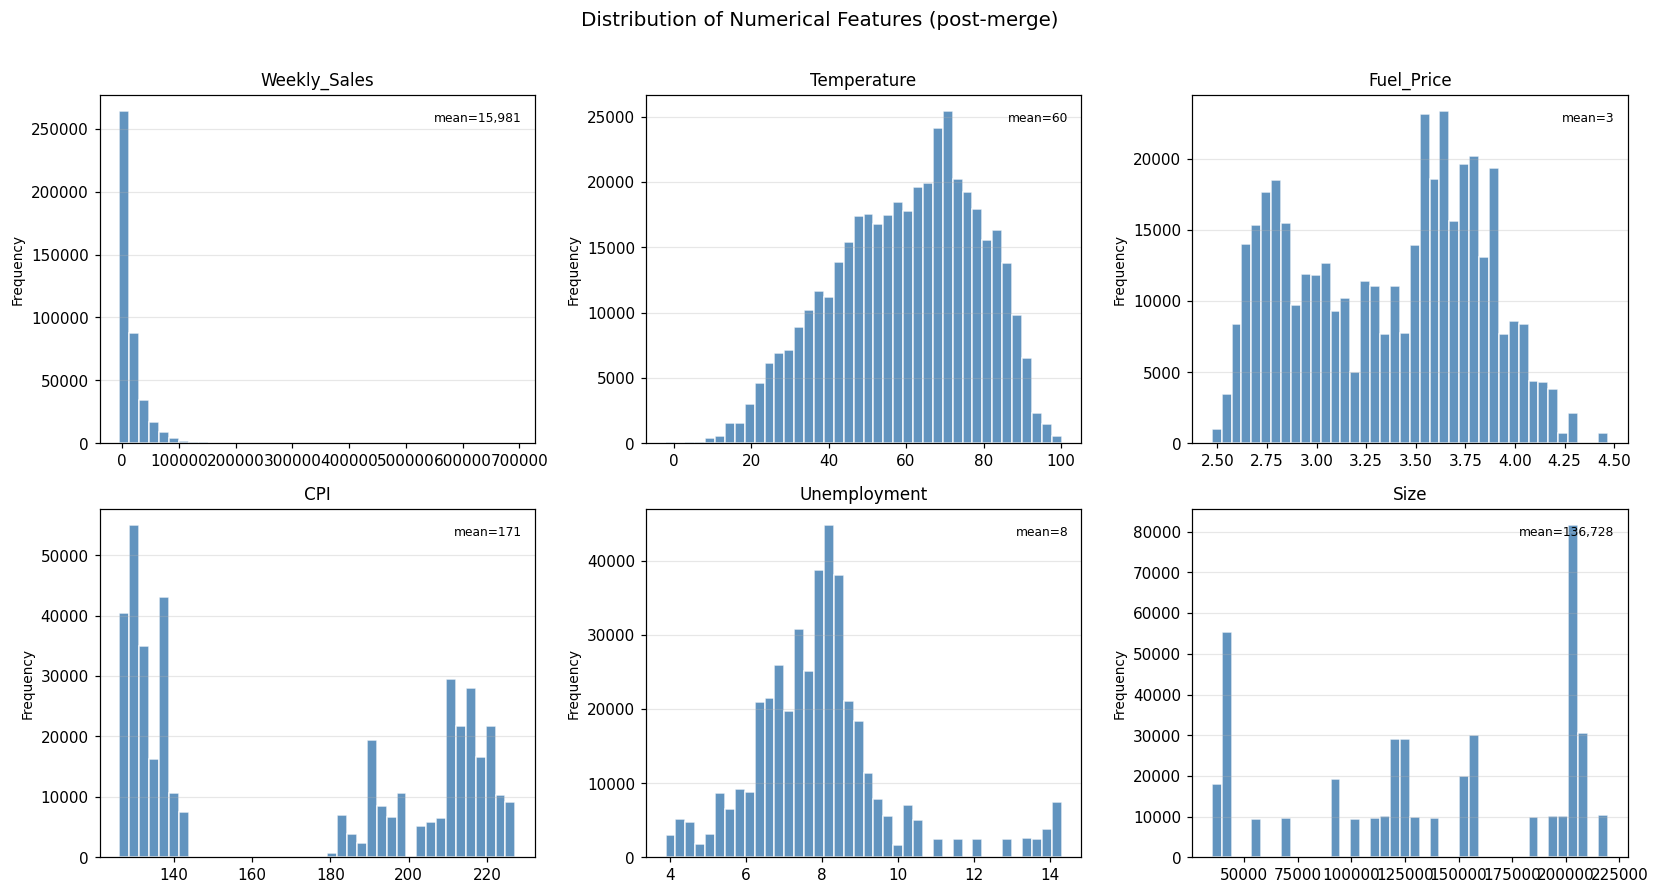

In [7]:
num_cols = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Size"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=PRIMARY_COLOR, edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.text(0.97, 0.95, f"mean={data.mean():,.0f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8)
plt.suptitle("Distribution of Numerical Features (post-merge)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

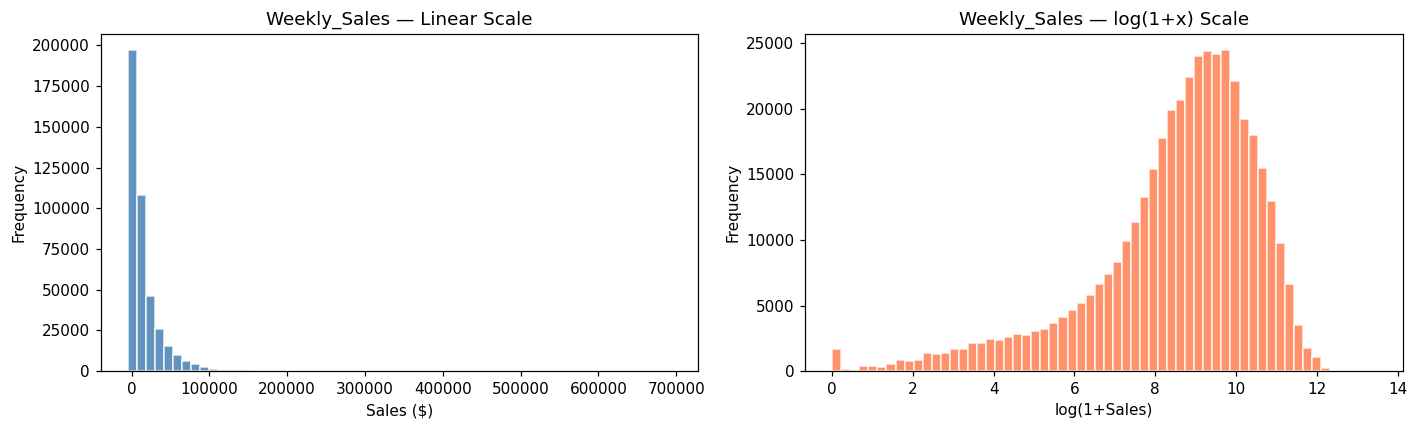

Note: 1285 rows have negative Weekly_Sales (markdowns/returns).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["Weekly_Sales"], bins=60, color=PRIMARY_COLOR, edgecolor="white", alpha=0.85)
axes[0].set_title("Weekly_Sales — Linear Scale", fontsize=12)
axes[0].set_xlabel("Sales ($)"); axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(df["Weekly_Sales"].clip(lower=0)), bins=60,
             color=SECONDARY_COLOR, edgecolor="white", alpha=0.85)
axes[1].set_title("Weekly_Sales — log(1+x) Scale", fontsize=12)
axes[1].set_xlabel("log(1+Sales)"); axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()
print(f"Note: {(df['Weekly_Sales'] < 0).sum()} rows have negative Weekly_Sales (markdowns/returns).")

---
## 5 · Time-Based Split Validation

In [9]:
train_mask = df["Date"] < TRAIN_END_DATE
val_mask   = (df["Date"] >= TRAIN_END_DATE) & (df["Date"] < VAL_END_DATE)
test_mask  = df["Date"] >= VAL_END_DATE

print(f"{'Set':<12} {'Rows':>8}  {'Date range'}")
print("-" * 55)
for mask, label in [(train_mask, "Train"), (val_mask, "Val"), (test_mask, "Test")]:
    sub = df[mask]
    print(f"{label:<12} {len(sub):>8,}  "
          f"{sub['Date'].min().date()} – {sub['Date'].max().date()}")

Set              Rows  Date range
-------------------------------------------------------
Train         356,489  2010-02-05 – 2012-05-25
Val            26,551  2012-06-01 – 2012-07-27
Test           38,530  2012-08-03 – 2012-10-26


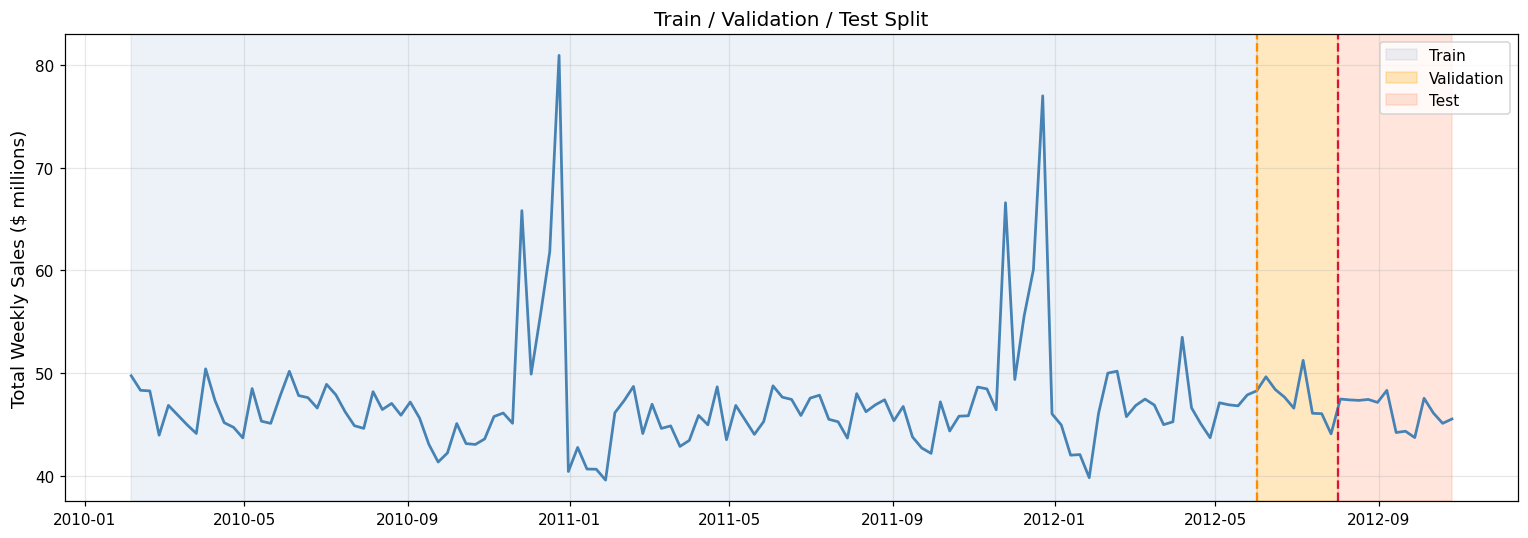

In [10]:
weekly = df.groupby("Date")["Weekly_Sales"].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly.index, weekly / 1e6, color=PRIMARY_COLOR, linewidth=1.8)

train_end = pd.Timestamp(TRAIN_END_DATE)
val_end   = pd.Timestamp(VAL_END_DATE)

ax.axvspan(weekly.index.min(), train_end,  alpha=0.10, color=PRIMARY_COLOR,   label="Train")
ax.axvspan(train_end,          val_end,    alpha=0.25, color="orange",         label="Validation")
ax.axvspan(val_end,            weekly.index.max(), alpha=0.20, color=SECONDARY_COLOR, label="Test")

ax.axvline(train_end, color="darkorange", linestyle="--", linewidth=1.5)
ax.axvline(val_end,   color="crimson",    linestyle="--", linewidth=1.5)

ax.set_title("Train / Validation / Test Split", fontsize=13)
ax.set_ylabel("Total Weekly Sales ($ millions)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### Pipeline Steps

| Step | Action | Result |
|------|--------|--------|
| Merge | train + features + stores (drop MarkDowns) | 421,570 rows × 11 cols |
| Missing externals | Forward/back-fill CPI, Unemployment, Temperature, Fuel_Price per store | 0 NaN remaining |
| Store type | One-hot encoded A/B/C → `Type_A`, `Type_B`, `Type_C` | 3 new columns |
| Raw split | Chronological cut by date | Train 356,489 · Val 26,551 · Test 38,530 rows |

### Raw Split (Before Lag Features)

| Set | Rows | Date range |
|-----|------|------------|
| Train | 356,489 | 2010-02-05 – 2012-05-25 |
| Validation | 26,551 | 2012-06-01 – 2012-07-27 |
| Test | 38,530 | 2012-08-03 – 2012-10-26 |

> **Note — Lag requirement**: When lag-52 features are added in Notebook 03, the first full year
> of data (≈160,000 rows) must be dropped because there is no 52-week history available.
> The model split after lag removal will be: **Train 197,201 · Val 26,017 · Test 37,865**.

**Next**: `03_time_features.ipynb` — create lag and rolling features for regression models.